# INNE (Isolation using Nearest Neighbor Ensemble) for Fraud Anomaly Detection

This script uses the `cms_general_payments_anomaly_ready.csv` or the `unified_dataset.csv` and applies the INNE algorithm for fraud anomaly detection. INNE is an unsupervised anomaly detection method that uses nearest-neighbor-based isolation. Unlike Isolation Forest, which partitions the global feature space using trees, INNE partitions the data space into hypersphere regions using subsamples and determines an isolation score based on how isolated a point is from its nearest neighbors — making it sensitive to local density anomalies that Isolation Forest can miss.

**Advantages over LOF (which this replaces in the ensemble):**
- Linear time complexity and constant space complexity (much faster than LOF on large or high-dimensional data)
- Detects both local and global anomalies
- Handles high-dimensional data with irrelevant attributes
- Overcomes weaknesses of Isolation Forest (local anomalies, axis-parallel masking, multimodal data)

The notebook includes:
- Data preprocessing with standard scaling
- **AUPRC-based hyperparameter tuning** (uses labeled fraud samples for validation)
- Anomaly score analysis
- Feature importance for anomaly detection
- Visualization of detected anomalies
- **Percentile binning** to Low / Medium / High / Critical severity labels
- **Confusion matrix based on top 5% anomalous threshold**
- **Aggregate anomaly scores -Year**aly scores 
- **Model export for ensemble integration**
mble integration**

The test data is 40% of the original data. This notebook takes 40 minutes to run!

## Install and Import Dependencies


In [1]:
!pip install pyod --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pyod.models.inne import INNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, precision_recall_curve,
    roc_auc_score
)
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif

import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('Imports OK')



Imports OK


## Configuration

This section defines the dataset path, core modeling columns, hyperparameter grid, score bins, and output artifacts used throughout the notebook.


In [3]:
# Dataset configurations
DATASET_CONFIGS = {
    "cms_general_payments": {
        "data_path": "/dsa/groups/casestudycf25/team02/silver/cms_general_payments_anomaly_ready.csv",
        "id_cols": ["covered_recipient_npi", "record_id", "program_year"],
        "target_col": "target",
        "provider_col": "covered_recipient_npi",
        "year_col": "program_year"
    },
    "legacy_unified_dataset": {
        "data_path": "/dsa/groups/casestudycf25/team02/gold/unified_dataset.csv",
        "id_cols": ["npi"],
        "target_col": "target",
        "provider_col": "npi",
        "year_col": "program_year"
    }
}

# Choose one active dataset
ACTIVE_DATASET = "cms_general_payments"
CFG = DATASET_CONFIGS[ACTIVE_DATASET]

# Dataset and core columns
DATA_PATH = CFG["data_path"]
ID_COLS = CFG["id_cols"]
TARGET_COL = CFG["target_col"]
PROVIDER_COL = CFG["provider_col"]
YEAR_COL = CFG["year_col"]
NULL_FILL = -1

# Train-test split
TEST_SIZE = 0.40
RANDOM_SEED = 42


# INNE hyperparameter search space
# n_estimators: more = more stable but slower
# max_samples:  subsample size; smaller = faster, larger = less local
# contamination: only affects the binary threshold, not the scores
# Best params: {'contamination': 0.0005, 'max_samples': 8, 'n_estimators': 100, 'random_state': 42}
PARAM_GRID = {
    'n_estimators':  [100],
    'max_samples':   [8],
    'contamination': [0.0005],
    'random_state':  [RANDOM_SEED],
}
TOP_K_MIN = 15

# Anomaly score bins applied to full-dataset scores
# Low  = [0, P50)
# Medium   = [P50, P90)
# High = [P90, P95)
# Critical = [P95, 100]
BIN_PERCENTILES = [50, 90, 95]
BIN_LABELS = ['Low', 'Medium', 'High', 'Critical']
REQUIRED_COLS = ID_COLS + [TARGET_COL, PROVIDER_COL, YEAR_COL]

#  Output filenames 
OUT_MODEL = 'inne_model.pkl'
OUT_SCALER = 'inne_scaler.pkl'
OUT_REFS = 'inne_reference_scores.pkl'
OUT_CSV = 'inne_predictions.csv'

print(f'Configuration loaded for dataset: {ACTIVE_DATASET}')
print(f'Data path: {DATA_PATH}')

Configuration loaded for dataset: cms_general_payments
Data path: /dsa/groups/casestudycf25/team02/silver/cms_general_payments_anomaly_ready.csv


## Load and Prepare Data


In [4]:
# Load the selected dataset and validate the required schema
df = pd.read_csv(DATA_PATH)

missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
if missing_cols:
    raise ValueError(
        f"Dataset '{ACTIVE_DATASET}' is missing required columns: {missing_cols}"
    )

print(f"Active dataset: {ACTIVE_DATASET}")
print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df[TARGET_COL].value_counts()}")
df.head()

Active dataset: cms_general_payments
Dataset shape: (932908, 53)
Target distribution:
target
0    932441
1       467
Name: count, dtype: int64


,record_id,covered_recipient_npi,target,total_amount_of_payment_us_dollars,avg_amount_per_payment,log_total_amount,number_of_payments_included_in_total_amount,payment_to_publication_lag_days,payment_month,payment_quarter,...,dme_hospital_beds,dme_replacement_batteries,dme_tapes_and_medical_supplies,nature_short_descr_enc,form_of_payment_or_transfer_of_value_enc,covered_recipient_primary_type_1_enc,recipient_state_enc,specialty_type_enc,specialty_lvl1_enc,specialty_enc
0,1006679101,1750964185,0,10.58,10.58,2.449279,1.0,640.0,9.0,3.0,...,0.0,0.0,0.0,7.0,2.0,5.0,2.0,5.0,1.0,61.0
1,1006696505,1417944091,0,8.23,8.23,2.222459,1.0,741.0,6.0,2.0,...,0.0,0.0,0.0,7.0,2.0,5.0,2.0,5.0,1.0,61.0
2,1006744861,1699208850,0,10.33,10.33,2.427454,1.0,880.0,2.0,1.0,...,0.0,0.0,0.0,7.0,2.0,4.0,8.0,4.0,7.0,72.0
3,1006725903,1124052717,0,6.57,6.57,2.024193,1.0,733.0,6.0,2.0,...,0.0,0.0,0.0,10.0,0.0,4.0,2.0,4.0,7.0,72.0
4,1006725915,1124052717,0,90.79,90.79,4.519503,1.0,714.0,7.0,3.0,...,0.0,0.0,0.0,7.0,2.0,4.0,2.0,4.0,7.0,72.0


In [5]:
df.to_csv("cms_general_payments_anomaly_ready.csv", index = False)

In [5]:
missing = df.isnull().sum()
print(f'Columns with nulls: {(missing > 0).sum()}')
if (missing > 0).any():
    print(missing[missing > 0].sort_values(ascending=False).head(10))

df = df.fillna(NULL_FILL)
print(f'Nulls filled with {NULL_FILL}.')

Columns with nulls: 0
Nulls filled with -1.


In [6]:
# Candidate feature set before dropping columns from modeling
drop_cols = ID_COLS + [TARGET_COL]
candidate_feature_cols = [c for c in df.columns if c not in drop_cols]

X_candidates = df[candidate_feature_cols].apply(pd.to_numeric, errors='coerce').fillna(NULL_FILL)
y = df[TARGET_COL].astype(int).values

TOP_K_FEATURES = min(TOP_K_MIN, X_candidates.shape[1])

selector = SelectKBest(score_func=mutual_info_classif, k=TOP_K_FEATURES)
selector.fit(X_candidates, y)

feature_rankings_df = (
    pd.DataFrame({
        "feature": X_candidates.columns,
        "mutual_info_score": selector.scores_,
        "selected": selector.get_support()
    })
    .sort_values(["selected", "mutual_info_score"], ascending=[False, False])
    .reset_index(drop=True)
)

selected_feature_cols = feature_rankings_df.loc[
    feature_rankings_df["selected"], "feature"
].tolist()

feature_cols = selected_feature_cols
X = X_candidates[feature_cols].values

print(f"Candidate features: {len(candidate_feature_cols)}")
print(f"Selected features:  {len(feature_cols)}")
print("\nTop selected features by mutual information:")
display(feature_rankings_df.head(20))

Candidate features: 49
Selected features:  15

Top selected features by mutual information:


,feature,mutual_info_score,selected
0,number_of_payments_included_in_total_amount,0.205533,True
1,is_third_party_payment,0.205226,True
2,form_of_payment_or_transfer_of_value_enc,0.178622,True
3,nature_short_descr_enc,0.157969,True
4,covered_device,0.149351,True
5,specialty_type_enc,0.109107,True
6,covered_recipient_primary_type_1_enc,0.104940,True
7,specialty_lvl1_enc,0.091607,True
8,payment_quarter,0.047654,True
9,is_q4_payment,0.041463,True


## Train-Test Split and Scaling


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, 
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape} \n  Test: {X_test_scaled.shape}')
print(f'Train fraud count: {y_train.sum()} \n  Test fraud count: {y_test.sum()}')

Train: (559744, 15) 
  Test: (373164, 15)
Train fraud count: 280 
  Test fraud count: 187


## AUPRC-Based Hyperparameter Tuning

Since we have labeled fraud samples in the target column, this PLAN notebook uses AUPRC to compare unsupervised INNE hyperparameter settings on the held-out test split.


In [8]:
results = []
param_list = list(ParameterGrid(PARAM_GRID))
print(f'Searching {len(param_list)} hyperparameter combinations...')

for i, params in enumerate(param_list, 1):
    model  = INNE(**params)
    model.fit(X_train_scaled)
    scores = model.decision_function(X_test_scaled)  # Higher = more anomalous
    auprc  = average_precision_score(y_test, scores)
    results.append({**params, 'auprc': auprc})
    print(f'  [{i}/{len(param_list)}] params={params} to AUPRC={auprc:.4f}')

results_df  = pd.DataFrame(results).sort_values('auprc', ascending=False)
best_params = results_df.iloc[0].drop('auprc').to_dict()

# Cast back integer params
for key in ['n_estimators', 'max_samples', 'random_state']:
    best_params[key] = int(best_params[key])
    
best_auprc  = results_df.iloc[0]['auprc']

print(f'\nBest AUPRC: {best_auprc:.4f}')
print(f'Best params: {best_params}')
results_df.head()

Searching 1 hyperparameter combinations...
  [1/1] params={'contamination': 0.0005, 'max_samples': 8, 'n_estimators': 100, 'random_state': 42} to AUPRC=0.0012

Best AUPRC: 0.0012
Best params: {'contamination': 0.0005, 'max_samples': 8, 'n_estimators': 100, 'random_state': 42}


,contamination,max_samples,n_estimators,random_state,auprc
0,0.0005,8,100,42,0.001217


In [9]:
##############################################
# Run History
###############################################

######## ALL FEATURES
# PARAM_GRID = {
#     'n_estimators':  [100, 200],
#     'max_samples':   [8, 16],
#     'contamination': [0.05, 0.10],
#     'random_state':  [RANDOM_SEED],
# }
# Best AUPRC: 0.0007
# Best params: {'contamination': 0.05, 'max_samples': 16, 'n_estimators': 200, 'random_state': 42}


############ WITH TOP K at 15:
# PARAM_GRID = {
#     'n_estimators':  [200],
#     'max_samples':   [16],
#     'contamination': [0.0005],
#     'random_state':  [RANDOM_SEED],
# }
# Best AUPRC: 0.0010
# Best params: {'contamination': 0.0005, 'max_samples': 16, 'n_estimators': 200, 'random_state': 42}
# Model AUPRC: 0.0010
# Dataset Baseline AUPRC: 0.0005
# Adjusted AUPRC: 0.0005
# Mann-Whitney U statistic: 48955069.0
# Mann-Whitney p: 5.793e-22

############# BEST IS TOP K at 15
# PARAM_GRID = {
#     'n_estimators':  [100, 200, 300],
#     'max_samples':   [8, 16, 32],
#     'contamination': [0.0005, 0.0003, 0.0004],
#     'random_state':  [RANDOM_SEED],
# }
# Best AUPRC: 0.0012
# Best params: {'contamination': 0.0005, 'max_samples': 8, 'n_estimators': 100, 'random_state': 42}
# Model AUPRC: 0.0012
# Dataset Baseline AUPRC: 0.0005
# Adjusted AUPRC: 0.0007
# Mann-Whitney U statistic: 50359065.5
# Mann-Whitney p: 3.681e-26

########### WITH TOP K at 25:
# PARAM_GRID = {
#     'n_estimators':  [200],
#     'max_samples':   [16],
#     'contamination': [0.0005],
#     'random_state':  [RANDOM_SEED],
# }
# Best AUPRC: 0.0009
# Best params: {'contamination': 0.0005, 'max_samples': 16, 'n_estimators': 200, 'random_state': 42}
# Model AUPRC: 0.0009
# Dataset Baseline AUPRC: 0.0005
# Adjusted AUPRC: 0.0004
# Mann-Whitney U statistic: 48106160.5
# Mann-Whitney p: 1.291e-19

############ WITH TOP K at 50:
# PARAM_GRID = {
#     'n_estimators':  [200],
#     'max_samples':   [16],
#     'contamination': [0.0005],
#     'random_state':  [RANDOM_SEED],
# }
# Best AUPRC: 0.0009
# Best params: {'contamination': 0.0005, 'max_samples': 16, 'n_estimators': 200, 'random_state': 42}
# Model AUPRC: 0.0009
# Dataset Baseline AUPRC: 0.0005
# Adjusted AUPRC: 0.0004
# Mann-Whitney U statistic: 48773125.5
# Mann-Whitney p: 1.897e-21

## Train Final Model with Best Parameters


In [10]:
inne = INNE(**best_params)
inne.fit(X_train_scaled)

train_scores     = inne.decision_function(X_train_scaled)
test_scores      = inne.decision_function(X_test_scaled)
test_predictions = inne.predict(X_test_scaled)   # 1 = anomaly, 0 = normal

X_all_scaled = scaler.transform(X)
all_scores   = inne.decision_function(X_all_scaled)

auprc_val = average_precision_score(y_test, test_scores)
roc_auc   = roc_auc_score(y_test, test_scores)

print('Scoring complete.')
print(f'  AUPRC (test): {auprc_val:.4f} \n  ROC-AUC (test): {roc_auc:.4f}')
print(f'  Score range (all): [{all_scores.min():.4f}, {all_scores.max():.4f}]')

Scoring complete.
  AUPRC (test): 0.0012 
  ROC-AUC (test): 0.7220
  Score range (all): [0.2367, 1.0000]


## Anomaly Score Distribution Analysis

The score bins below are derived from the full dataset so the same thresholds can be reused consistently in downstream scoring.


In [11]:
cutoffs = np.percentile(all_scores, BIN_PERCENTILES)
print(f'Bin cutoffs (percentiles {BIN_PERCENTILES}): {cutoffs.round(4)}')

def assign_bins(scores, cutoffs, labels):
    """Assign scores to named bins using fixed percentile cutoffs."""
    bins = np.full(len(scores), labels[0], dtype=object)
    for cutoff, label in zip(cutoffs, labels[1:]):
        bins[scores >= cutoff] = label
    return bins

all_bins   = assign_bins(all_scores,   cutoffs, BIN_LABELS)
train_bins = assign_bins(train_scores, cutoffs, BIN_LABELS)
test_bins  = assign_bins(test_scores,  cutoffs, BIN_LABELS)

bin_counts = pd.Series(all_bins).value_counts().reindex(BIN_LABELS)
print('\nBin distribution (full dataset):')
print(bin_counts.to_frame('count').assign(pct=lambda d: (d['count']/len(all_bins)*100).round(1)))

Bin cutoffs (percentiles [50, 90, 95]): [0.5959 0.8927 0.9102]

Bin distribution (full dataset):
           count   pct
Low       466439  50.0
Medium    367442  39.4
High       52334   5.6
Critical   46693   5.0


## Visual Verification Dashboard


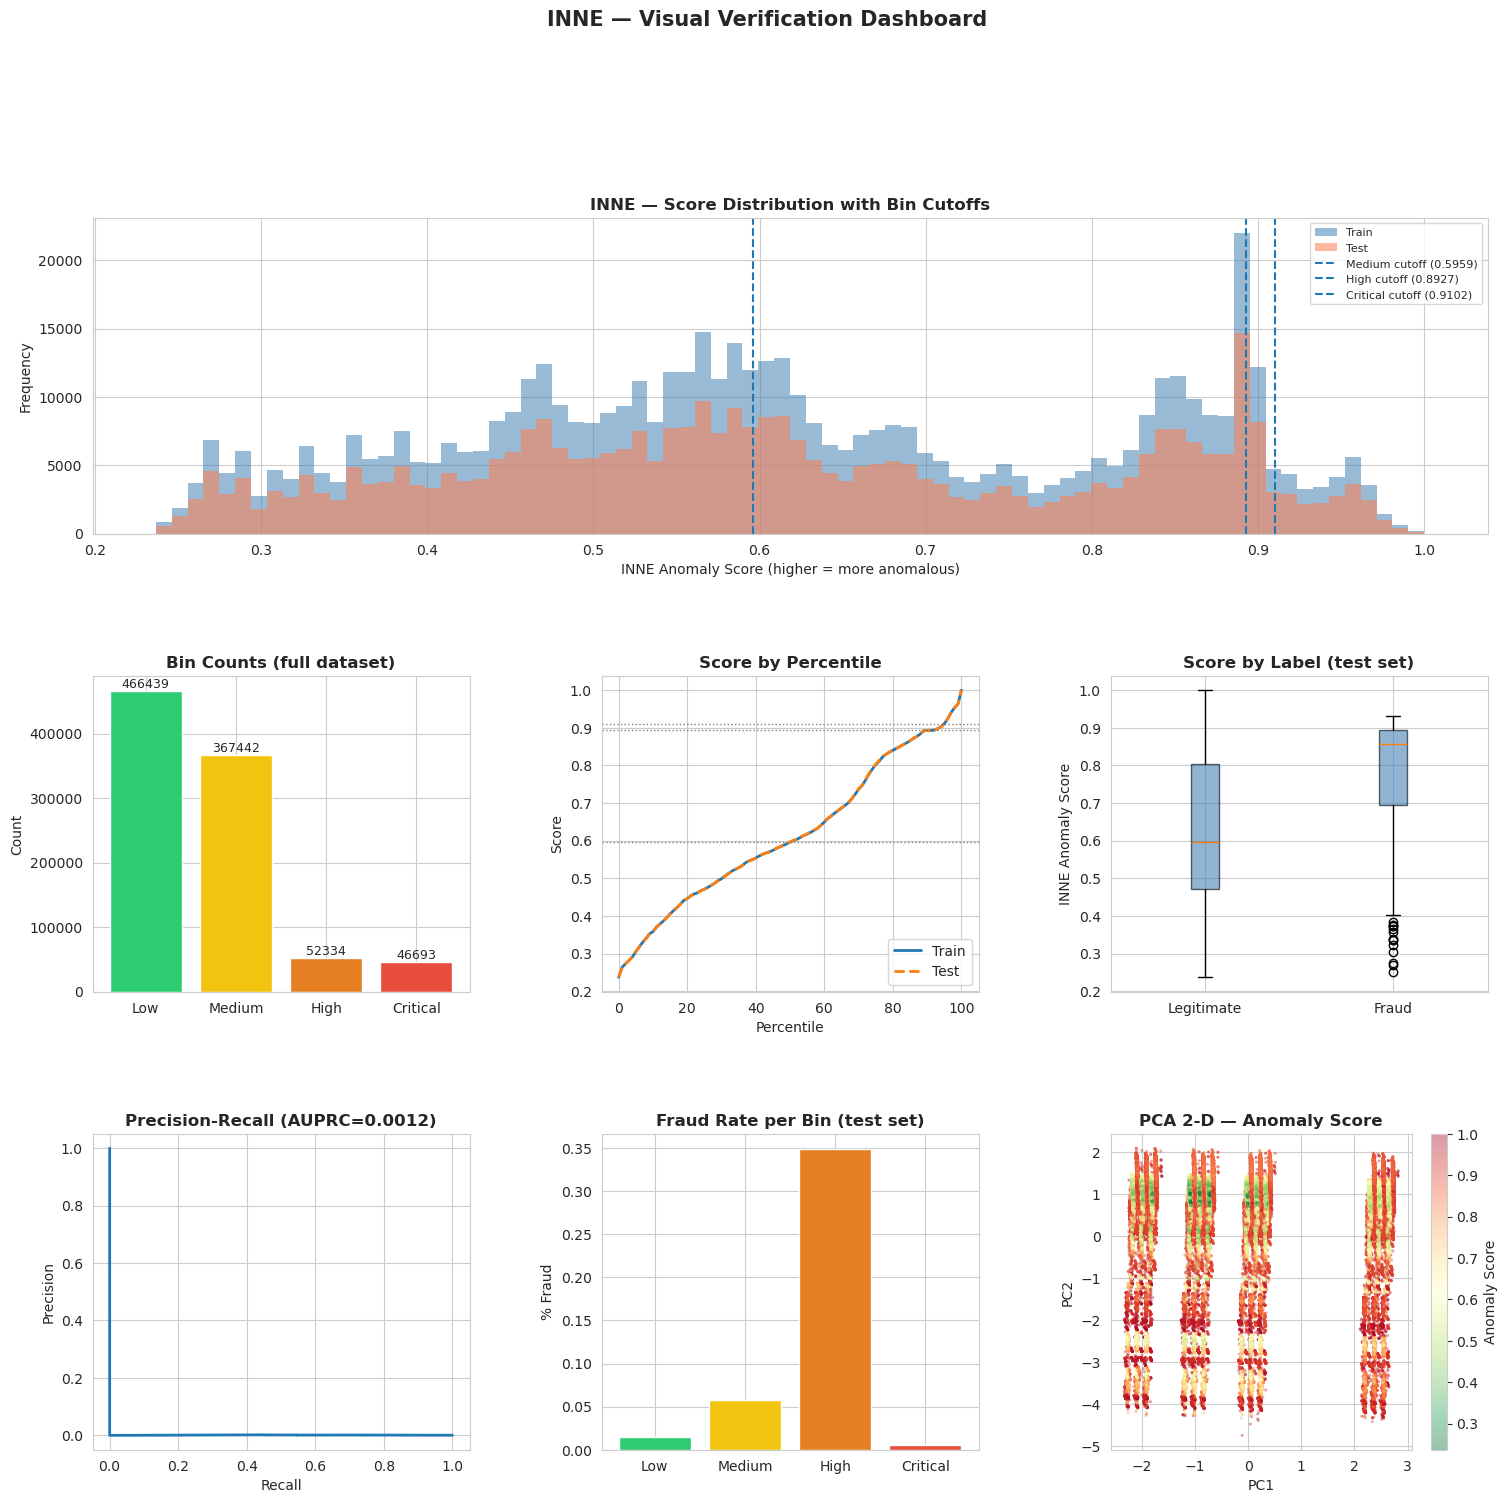


Summary: best AUPRC=0.0012
 test AUPRC=0.0012
 Critical count=46693 (5.0%)


In [12]:
fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

#  Panel A: Score distribution 
ax_a = fig.add_subplot(gs[0, :])
ax_a.hist(train_scores, bins=80, alpha=0.55, label='Train', color='steelblue', edgecolor='none')
ax_a.hist(test_scores,  bins=80, alpha=0.55, label='Test',  color='coral',     edgecolor='none')
for c, lbl in zip(cutoffs, BIN_LABELS[1:]):
    ax_a.axvline(c, linestyle='--', linewidth=1.5, label=f'{lbl} cutoff ({c:.4f})')
ax_a.set_xlabel('INNE Anomaly Score (higher = more anomalous)')
ax_a.set_ylabel('Frequency')
ax_a.set_title('INNE — Score Distribution with Bin Cutoffs', fontweight='bold')
ax_a.legend(fontsize=8)

#  Panel B: Bin bar chart 
ax_b = fig.add_subplot(gs[1, 0])
ax_b.bar(BIN_LABELS, bin_counts.values, color=colors, edgecolor='white')
ax_b.set_title('Bin Counts (full dataset)', fontweight='bold')
ax_b.set_ylabel('Count')
for i, v in enumerate(bin_counts.values):
    ax_b.text(i, v + max(bin_counts)*0.01, str(v), ha='center', fontsize=9)

#  Panel C: Percentile curve 
ax_c = fig.add_subplot(gs[1, 1])
pcts = np.arange(0, 101, 1)
ax_c.plot(pcts, np.percentile(train_scores, pcts), label='Train', linewidth=2)
ax_c.plot(pcts, np.percentile(test_scores,  pcts), label='Test',  linewidth=2, linestyle='--')
for c in cutoffs:
    ax_c.axhline(c, color='grey', linestyle=':', linewidth=1)
ax_c.set_xlabel('Percentile')
ax_c.set_ylabel('Score')
ax_c.set_title('Score by Percentile', fontweight='bold')
ax_c.legend()

#  Panel D: Boxplot by label 
ax_d = fig.add_subplot(gs[1, 2])
ax_d.boxplot(
    [test_scores[y_test == 0], test_scores[y_test == 1]],
    labels=['Legitimate', 'Fraud'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
)
ax_d.set_title('Score by Label (test set)', fontweight='bold')
ax_d.set_ylabel('INNE Anomaly Score')

#  Panel E: Precision-Recall 
ax_e = fig.add_subplot(gs[2, 0])
prec, rec, _ = precision_recall_curve(y_test, test_scores)
ax_e.plot(rec, prec, linewidth=2)
ax_e.set_xlabel('Recall')
ax_e.set_ylabel('Precision')
ax_e.set_title(f'Precision-Recall (AUPRC={auprc_val:.4f})', fontweight='bold')
ax_e.fill_between(rec, prec, alpha=0.15)

#  Panel F: Fraud rate per bin 
ax_f = fig.add_subplot(gs[2, 1])
test_bin_series = pd.Series(test_bins)
fraud_rate = pd.Series({
    lbl: y_test[test_bin_series == lbl].mean()
    for lbl in BIN_LABELS
})
ax_f.bar(fraud_rate.index, fraud_rate.values * 100, color=colors, edgecolor='white')
ax_f.set_title('Fraud Rate per Bin (test set)', fontweight='bold')
ax_f.set_ylabel('% Fraud')

#  Panel G: PCA 2-D scatter 
ax_g = fig.add_subplot(gs[2, 2])
pca = PCA(n_components=2, random_state=RANDOM_SEED)
Xt  = pca.fit_transform(X_test_scaled)
sc  = ax_g.scatter(Xt[:, 0], Xt[:, 1], c=test_scores, cmap='RdYlGn_r',
                   alpha=0.4, s=5, linewidths=0)
plt.colorbar(sc, ax=ax_g, label='Anomaly Score')
ax_g.set_title('PCA 2-D — Anomaly Score', fontweight='bold')
ax_g.set_xlabel('PC1')
ax_g.set_ylabel('PC2')

fig.suptitle('INNE — Visual Verification Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.show()
print(f'\nSummary: best AUPRC={best_auprc:.4f}\n test AUPRC={auprc_val:.4f}\n '
      f'Critical count={int(bin_counts["Critical"])} ({int(bin_counts["Critical"])/len(all_bins)*100:.1f}%)')

## Feature Importance Analysis


In [13]:
# baseline     = test_scores.mean()
# importances  = []

# print(f'Computing permutation importance for {len(feature_cols)} features...')
# for i, feat in enumerate(feature_cols):
#     X_perm = X_test_scaled.copy()
#     np.random.shuffle(X_perm[:, i])
#     perm_scores = inne.decision_function(X_perm)
#     importances.append(baseline - perm_scores.mean())

# importance_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
# importance_df = importance_df.sort_values('importance', ascending=False).head(20)

# fig, ax = plt.subplots(figsize=(12, 7))
# sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis_r', ax=ax)
# ax.set_title('Top 20 Feature Importances (permutation — INNE)', fontweight='bold')
# ax.set_xlabel('Mean anomaly-score change when feature shuffled')
# plt.tight_layout()
# plt.show()

# importance_df

## Confusion Matrix (Top 5% Anomalous as Predicted Fraud)


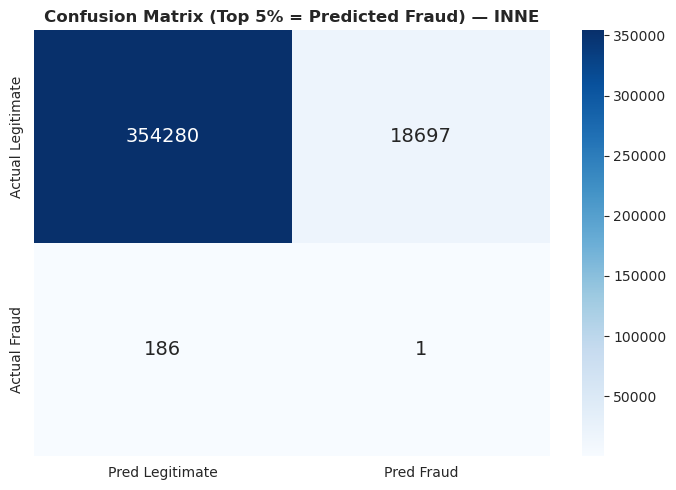

              precision    recall  f1-score   support

  Legitimate       1.00      0.95      0.97    372977
       Fraud       0.00      0.01      0.00       187

    accuracy                           0.95    373164
   macro avg       0.50      0.48      0.49    373164
weighted avg       1.00      0.95      0.97    373164

Fraud capture rate in top 5%: 1/187 = 0.5%


In [14]:
top5_cutoff  = np.percentile(test_scores, 95)
y_pred_top5  = (test_scores >= top5_cutoff).astype(int)
cm           = confusion_matrix(y_test, y_pred_top5)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Legitimate', 'Pred Fraud'],
            yticklabels=['Actual Legitimate', 'Actual Fraud'],
            annot_kws={'size': 14}, ax=ax)
ax.set_title('Confusion Matrix (Top 5% = Predicted Fraud) — INNE', fontweight='bold')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_top5, target_names=['Legitimate', 'Fraud']))
print(f'Fraud capture rate in top 5%: {tp}/{tp+fn} = {tp/(tp+fn)*100:.1f}%')

## Save Model and Artifacts for Ensemble Integration


In [15]:
joblib.dump(inne,   OUT_MODEL)
joblib.dump(scaler, OUT_SCALER)

reference_data = {
    'model_type':         'inne',
    'best_params':        best_params,
    'best_auprc':         float(best_auprc),
    'auprc':              float(auprc_val),
    'roc_auc':            float(roc_auc),
    'feature_cols':       feature_cols,
    'bin_percentiles':    BIN_PERCENTILES,
    'bin_labels':         BIN_LABELS,
    'bin_cutoffs':        cutoffs.tolist(),
    'all_score_mean':     float(all_scores.mean()),
    'all_score_std':      float(all_scores.std()),
    # 'feature_importance': importance_df.set_index('feature')['importance'].to_dict(),
}
joblib.dump(reference_data, OUT_REFS)

out_df = df[ID_COLS + [TARGET_COL]].copy()
out_df['inne_anomaly_score'] = all_scores
out_df['inne_anomaly_bin']   = all_bins
out_df = out_df.sort_values('inne_anomaly_score', ascending=False)
out_df.to_csv(OUT_CSV, index=False)

print(f'Model  to {OUT_MODEL}')
print(f'Scaler to {OUT_SCALER}')
print(f'Refs   to {OUT_REFS}')
print(f'CSV    to {OUT_CSV}')
print(f'\nBin cutoffs persisted: {dict(zip(BIN_PERCENTILES, cutoffs.round(4)))}')
print(f'\nTop 10 most anomalous records:')
out_df.head(10)

Model  to inne_model.pkl
Scaler to inne_scaler.pkl
Refs   to inne_reference_scores.pkl
CSV    to inne_predictions.csv

Bin cutoffs persisted: {50: 0.5959, 90: 0.8927, 95: 0.9102}

Top 10 most anomalous records:


,covered_recipient_npi,record_id,program_year,target,inne_anomaly_score,inne_anomaly_bin
349559,1346237088,1059314685,2023.0,0,1.0,Critical
796347,1346237088,961696057,2022.0,0,1.0,Critical
491811,1407954035,998940529,2023.0,0,1.0,Critical
666138,1346237088,961695785,2022.0,0,1.0,Critical
819120,1487876017,850896945,2021.0,0,1.0,Critical
189697,1841417896,855192929,2021.0,0,1.0,Critical
36922,1124085485,850897015,2021.0,0,1.0,Critical
268194,1346237088,1059314599,2023.0,0,1.0,Critical
330269,1346237088,961696125,2022.0,0,1.0,Critical
199346,1992757181,961688189,2022.0,0,1.0,Critical


In [16]:
#########################################################
# Aggregate INNE Scores to Provider-Year
#########################################################
PROVIDER_COL = ID_COLS[0]          # 'covered_recipient_npi'
YEAR_COL     = ID_COLS[2]          # 'program_year'
CRITICAL_BIN = BIN_LABELS[-1]      # 'Critical'
HIGH_BIN     = BIN_LABELS[-2]      # 'High'
P90_CUTOFF   = cutoffs[1]          # 90th percentile
P95_CUTOFF   = cutoffs[2]          # 95th percentile

# Re-attach identifiers and scores to a single working frame
rollup_df = df[ID_COLS + [TARGET_COL]].copy()
rollup_df['inne_score'] = all_scores
rollup_df['inne_bin']   = all_bins

# Aggregate to provider-year
provider_year = rollup_df.groupby([PROVIDER_COL, YEAR_COL]).agg(
    inne_tx_count         = ('inne_score', 'count'),
    inne_score_mean       = ('inne_score', 'mean'),
    inne_score_max        = ('inne_score', 'max'),
    inne_score_std        = ('inne_score', 'std'),
    inne_n_above_p90      = ('inne_score', lambda s: (s >= P90_CUTOFF).sum()),
    inne_n_above_p95      = ('inne_score', lambda s: (s >= P95_CUTOFF).sum()),
    inne_pct_flagged      = ('inne_score', lambda s: (s >= P95_CUTOFF).mean()),
    inne_n_critical       = ('inne_bin',   lambda s: (s == CRITICAL_BIN).sum()),
    inne_pct_critical     = ('inne_bin',   lambda s: (s == CRITICAL_BIN).mean()),
    inne_has_any_critical = ('inne_bin',   lambda s: int((s == CRITICAL_BIN).any())),
    target                = (TARGET_COL,   'max'),
).reset_index()

OUT_ROLLUP = 'inne_provider_year_rollup.csv'
output_path = "/dsa/groups/casestudycf25/team02/silver/" + OUT_ROLLUP 
provider_year.to_csv(output_path, index=False)

print(f'Provider-year rollup shape: {provider_year.shape}')
print(f'Providers with any Critical transaction: {provider_year["inne_has_any_critical"].sum()}')
print(f'Saved → {OUT_ROLLUP}')
provider_year.head()

Provider-year rollup shape: (158751, 13)
Providers with any Critical transaction: 16551
Saved → inne_provider_year_rollup.csv


,covered_recipient_npi,program_year,inne_tx_count,inne_score_mean,inne_score_max,inne_score_std,inne_n_above_p90,inne_n_above_p95,inne_pct_flagged,inne_n_critical,inne_pct_critical,inne_has_any_critical,target
0,1003000597,2021.0,4,0.478279,0.517242,0.042183,0,0,0.000000,0,0.000000,0,0
1,1003000597,2022.0,17,0.596811,0.848592,0.142827,0,0,0.000000,0,0.000000,0,0
2,1003000597,2023.0,30,0.502890,0.912507,0.096942,1,1,0.033333,1,0.033333,1,0
3,1003000902,2021.0,1,0.892034,0.892034,NaN,0,0,0.000000,0,0.000000,0,0
4,1003000902,2022.0,1,0.892737,0.892737,NaN,1,0,0.000000,0,0.000000,0,0


In [17]:
from sklearn.metrics import average_precision_score
from scipy.stats import mannwhitneyu
import numpy as np

# Keep only labeled rows
labeled = out_df.dropna(subset=[TARGET_COL]).copy()

# Pull the held-out test-set scores and labels for evaluation
test_eval = pd.DataFrame({
    "target": y_test,
    "inne_anomaly_score": test_scores
}).dropna(subset=["target"])

# Compute the baseline prevalence on the held-out test set
baseline = test_eval["target"].mean()

# Compute AUPRC using the correct score direction; higher score = more anomalous
auprc = average_precision_score(
    test_eval["target"],
    test_eval["inne_anomaly_score"]
)

# Compute adjusted AUPRC relative to the baseline prevalence
adjusted_auprc = (auprc - baseline) / (1 - baseline)

# Split test scores by class for an independent-samples rank test
fraud_scores = test_eval.loc[
    test_eval["target"] == 1,
    "inne_anomaly_score"
].to_numpy()

normal_scores = test_eval.loc[
    test_eval["target"] == 0,
    "inne_anomaly_score"
].to_numpy()

# Run a one-sided Mann-Whitney U test; fraud should have higher anomaly scores
u_stat, p = mannwhitneyu(
    fraud_scores,
    normal_scores,
    alternative="greater",
    method="asymptotic"
)

# Guard against underflow when formatting extremely small p-values
p_display = f"{p:.3e}" if p > 0 else "< 1e-308"

# Print a clean summary
print(
    "DECISION GATE 2 - Isolation Using Nearest Neighbors Ensemble:\n"
    f"Model AUPRC: {auprc:.4f}\n"
    f"Dataset Baseline AUPRC: {baseline:.4f}\n"
    f"Adjusted AUPRC: {adjusted_auprc:.4f}\n"
    f"Mann-Whitney U statistic: {u_stat:.1f}\n"
    f"Mann-Whitney p: {p_display}"
)

DECISION GATE 2 - Isolation Using Nearest Neighbors Ensemble:
Model AUPRC: 0.0012
Dataset Baseline AUPRC: 0.0005
Adjusted AUPRC: 0.0007
Mann-Whitney U statistic: 50359065.5
Mann-Whitney p: 3.681e-26
